In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Dataset path
data_path = "../data/traffic_dataset.csv"

# Output folder
output_dir = "../outputs"

# Create output folder if it does not exist
os.makedirs(output_dir, exist_ok=True)

print("Output folder is ready!")
print("Graphs will be saved in:", os.path.abspath(output_dir))

Output folder is ready!
Graphs will be saved in: d:\Traffice-System\outputs


In [5]:
df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (254, 10)


In [6]:

df.head()

,filename,date,timestamp,direction,day_night,weather,start_frame,number_of_frames,traffic_class,notes
0,cctv052x2004080516x01638,20040805,16.01638,south,day,overcast,2,53,medium,NaN
1,cctv052x2004080516x01639,20040805,16.01639,south,day,overcast,2,53,medium,NaN
2,cctv052x2004080516x01640,20040805,16.01640,south,day,overcast,2,48,light,NaN
3,cctv052x2004080516x01641,20040805,16.01641,south,day,overcast,2,52,medium,NaN
4,cctv052x2004080516x01642,20040805,16.01642,south,day,overcast,2,51,medium,NaN


In [7]:
df.tail()

,filename,date,timestamp,direction,day_night,weather,start_frame,number_of_frames,traffic_class,notes
249,cctv052x2004080619x00104,20040806,19.00104,south,day,clear,2,53,light,NaN
250,cctv052x2004080620x00105,20040806,20.00105,south,day,clear,2,52,light,NaN
251,cctv052x2004080620x00106,20040806,20.00106,south,day,clear,2,53,light,NaN
252,cctv052x2004080620x00107,20040806,20.00107,south,day,clear,2,53,light,NaN
253,cctv052x2004080620x00108,20040806,20.00108,south,day,clear,2,52,light,NaN


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   filename          254 non-null    str    
 1   date              254 non-null    int64  
 2   timestamp         254 non-null    float64
 3   direction         254 non-null    str    
 4   day_night         254 non-null    str    
 5   weather           254 non-null    str    
 6   start_frame       254 non-null    int64  
 7   number_of_frames  254 non-null    int64  
 8   traffic_class     254 non-null    str    
 9   notes             14 non-null     str    
dtypes: float64(1), int64(3), str(6)
memory usage: 20.0 KB


In [9]:
df.describe(include="all")

,filename,date,timestamp,direction,day_night,weather,start_frame,number_of_frames,traffic_class,notes
count,254,2.540000e+02,254.000000,254,254,254,254.0,254.000000,254,14
unique,254,NaN,NaN,1,1,3,NaN,NaN,3,2
top,cctv052x2004080516x01638,NaN,NaN,south,day,overcast,NaN,NaN,light,drops on lens
freq,1,NaN,NaN,254,254,125,NaN,NaN,165,13
mean,NaN,2.004081e+07,13.841694,NaN,NaN,NaN,2.0,52.429134,NaN,NaN
std,NaN,4.280224e-01,4.278468,NaN,NaN,NaN,0.0,1.297953,NaN,NaN
min,NaN,2.004080e+07,6.018200,NaN,NaN,NaN,2.0,43.000000,NaN,NaN
25%,NaN,2.004081e+07,10.018853,NaN,NaN,NaN,2.0,52.000000,NaN,NaN
50%,NaN,2.004081e+07,15.000355,NaN,NaN,NaN,2.0,53.000000,NaN,NaN
75%,NaN,2.004081e+07,17.016627,NaN,NaN,NaN,2.0,53.000000,NaN,NaN


In [10]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
filename              0
date                  0
timestamp             0
direction             0
day_night             0
weather               0
start_frame           0
number_of_frames      0
traffic_class         0
notes               240
dtype: int64


In [11]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [12]:
for column in df.columns:
    print("\nColumn:", column)
    print(df[column].unique())


Column: filename
<StringArray>
['cctv052x2004080516x01638', 'cctv052x2004080516x01639',
 'cctv052x2004080516x01640', 'cctv052x2004080516x01641',
 'cctv052x2004080516x01642', 'cctv052x2004080516x01643',
 'cctv052x2004080516x01644', 'cctv052x2004080516x01645',
 'cctv052x2004080516x01646', 'cctv052x2004080516x01647',
 ...
 'cctv052x2004080619x00099', 'cctv052x2004080619x00100',
 'cctv052x2004080619x00101', 'cctv052x2004080619x00102',
 'cctv052x2004080619x00103', 'cctv052x2004080619x00104',
 'cctv052x2004080620x00105', 'cctv052x2004080620x00106',
 'cctv052x2004080620x00107', 'cctv052x2004080620x00108']
Length: 254, dtype: str

Column: date
[20040805 20040806]

Column: timestamp
[16.01638 16.01639 16.0164  16.01641 16.01642 16.01643 16.01644 16.01645
 16.01646 16.01647 16.01648 16.01649 16.0165  17.01652 17.01653 17.01654
 17.01655 17.01656 17.01657 17.01658 17.01659 17.0166  17.01661 17.01662
 17.01663 17.01664 17.01665 18.01666 18.01667 18.01668 18.01669 18.0167
 18.01671 18.01672 18.016

In [13]:
print("Number of unique values in each column:")
print(df.nunique())

Number of unique values in each column:
filename            254
date                  2
timestamp           254
direction             1
day_night             1
weather               3
start_frame           1
number_of_frames      9
traffic_class         3
notes                 2
dtype: int64


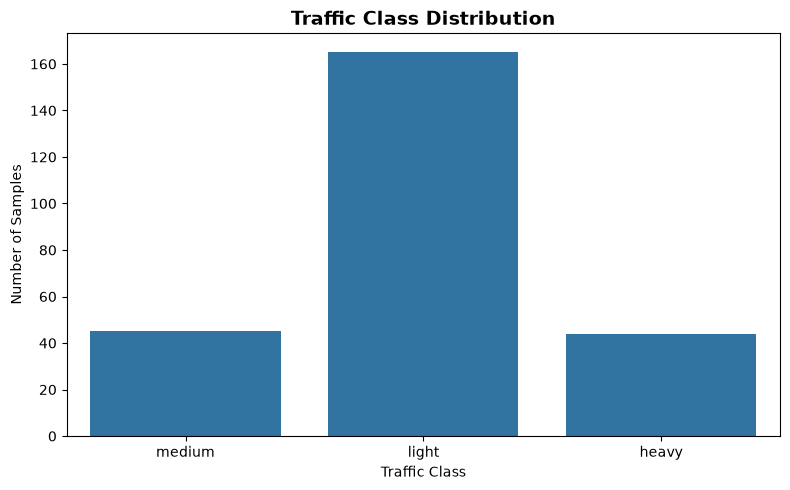

Exported graph to: ../outputs\traffic_class_distribution.png


In [14]:
# Create Traffic Class Distribution
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="traffic_class")

plt.title("Traffic Class Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Traffic Class")
plt.ylabel("Number of Samples")
plt.tight_layout()

# Export Graph
class_path = os.path.join(output_dir, "traffic_class_distribution.png")
plt.savefig(class_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Exported graph to: {class_path}")

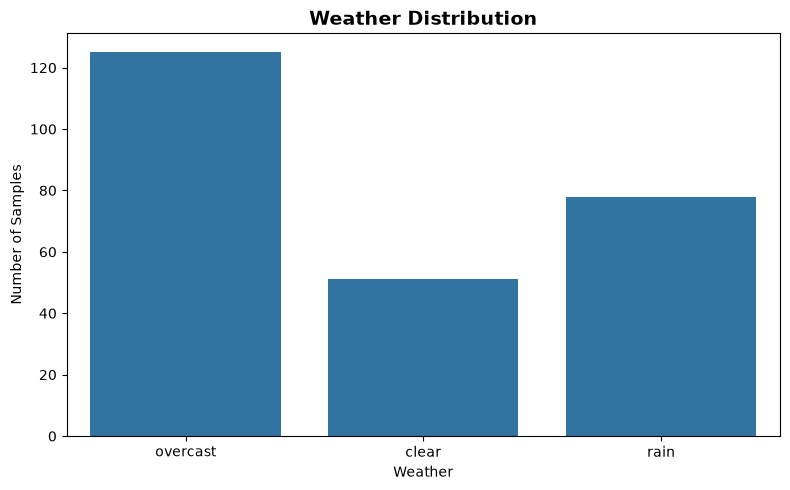

Exported graph to: ../outputs\weather_distribution.png


In [15]:
# Create Weather Distribution
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="weather")

plt.title("Weather Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Weather")
plt.ylabel("Number of Samples")
plt.tight_layout()

# Export Graph
weather_path = os.path.join(output_dir, "weather_distribution.png")
plt.savefig(weather_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Exported graph to: {weather_path}")

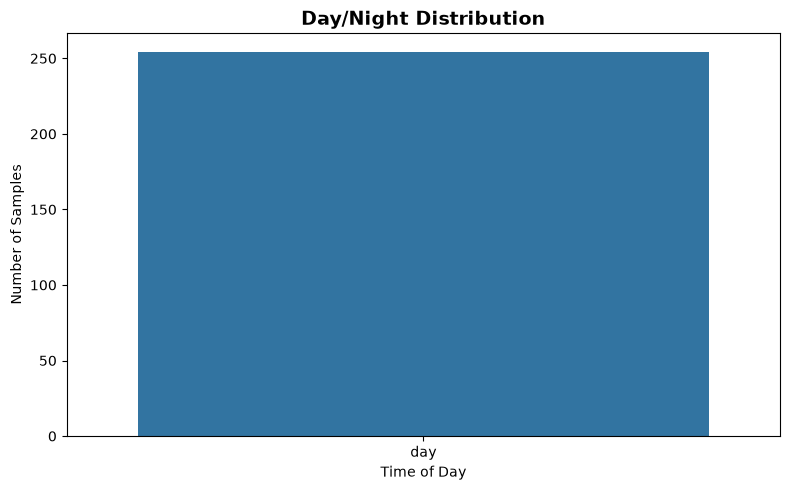

Exported graph to: ../outputs\day_night_distribution.png


In [16]:
# Create Day/Night Distribution
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="day_night")

plt.title("Day/Night Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Time of Day")
plt.ylabel("Number of Samples")
plt.tight_layout()

# Export Graph
day_night_path = os.path.join(output_dir, "day_night_distribution.png")
plt.savefig(day_night_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Exported graph to: {day_night_path}")

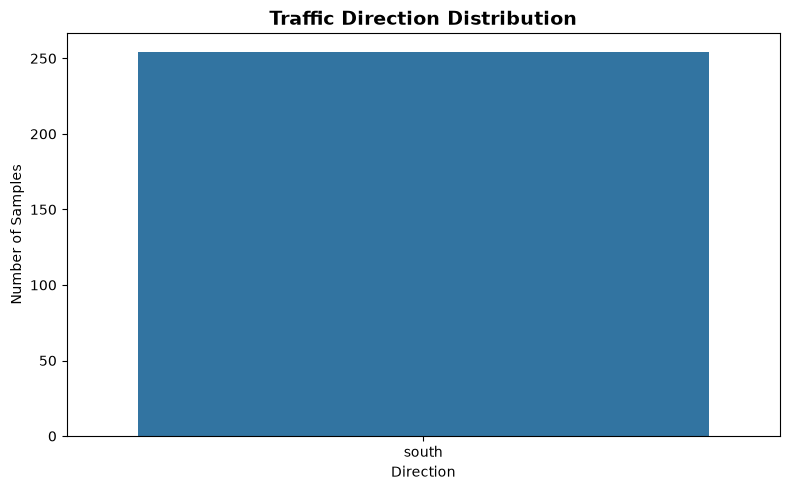

Exported graph to: ../outputs\direction_distribution.png


In [17]:
# Create Direction Distribution
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="direction")

plt.title("Traffic Direction Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Direction")
plt.ylabel("Number of Samples")
plt.tight_layout()

# Export Graph
direction_path = os.path.join(output_dir, "direction_distribution.png")
plt.savefig(direction_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Exported graph to: {direction_path}")

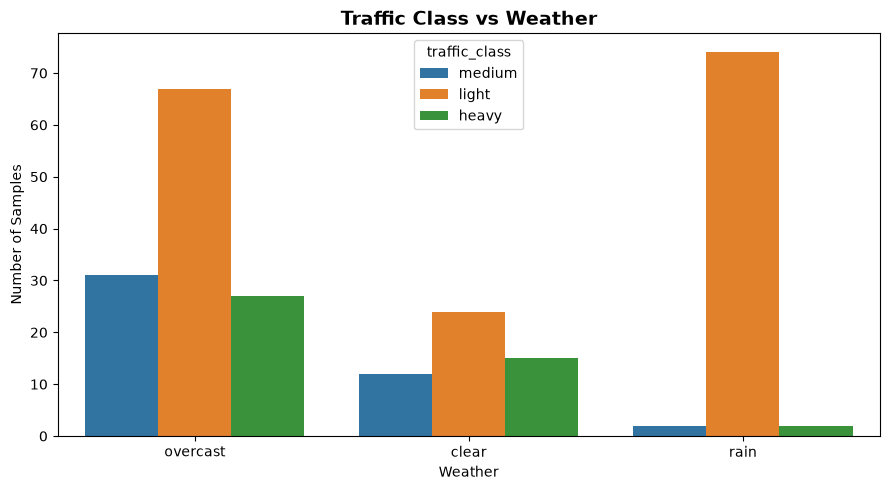

Exported graph to: ../outputs\traffic_class_vs_weather.png


In [18]:
# Traffic Class vs Weather
plt.figure(figsize=(9,5))

sns.countplot(data=df, x="weather", hue="traffic_class")

plt.title("Traffic Class vs Weather", fontsize=14, fontweight="bold")
plt.xlabel("Weather")
plt.ylabel("Number of Samples")
plt.tight_layout()

# Export Graph
traffic_weather_path = os.path.join(
    output_dir, "traffic_class_vs_weather.png"
)

plt.savefig(traffic_weather_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Exported graph to: {traffic_weather_path}")

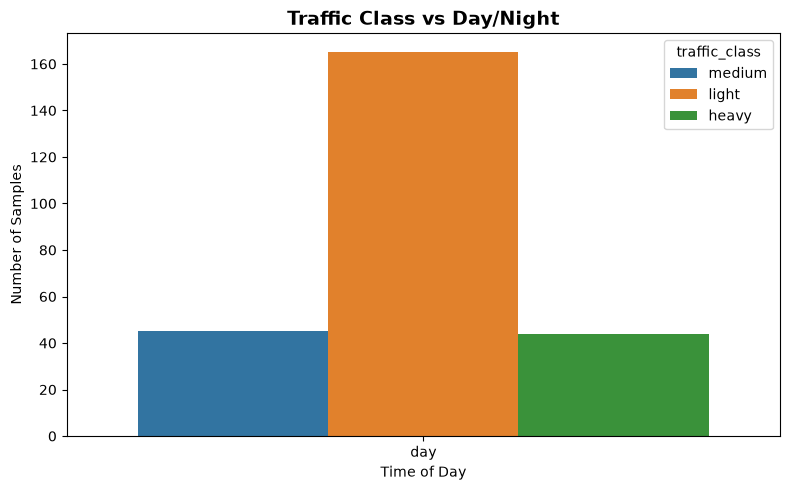

Exported graph to: ../outputs\traffic_class_vs_day_night.png


In [19]:
# Traffic Class vs Day/Night
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="day_night", hue="traffic_class")

plt.title("Traffic Class vs Day/Night", fontsize=14, fontweight="bold")
plt.xlabel("Time of Day")
plt.ylabel("Number of Samples")
plt.tight_layout()

# Export Graph
traffic_day_path = os.path.join(
    output_dir, "traffic_class_vs_day_night.png"
)

plt.savefig(traffic_day_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Exported graph to: {traffic_day_path}")

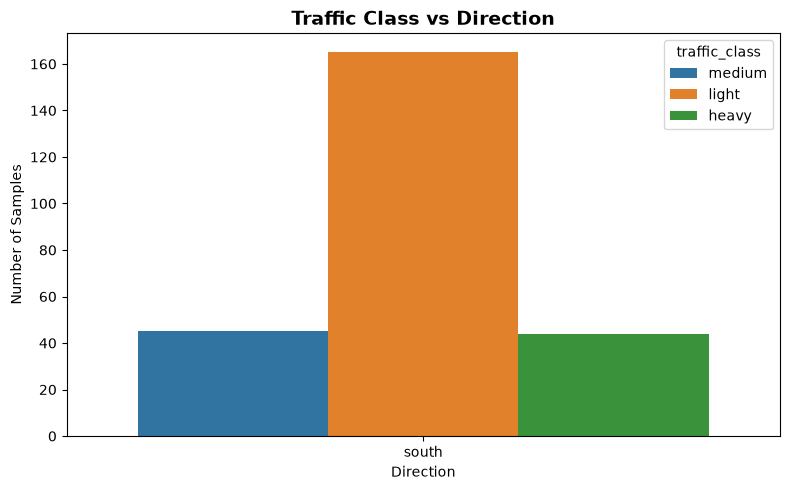

Exported graph to: ../outputs\traffic_class_vs_direction.png


In [20]:
# Traffic Class vs Direction
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="direction", hue="traffic_class")

plt.title("Traffic Class vs Direction", fontsize=14, fontweight="bold")
plt.xlabel("Direction")
plt.ylabel("Number of Samples")
plt.tight_layout()

# Export Graph
traffic_direction_path = os.path.join(
    output_dir, "traffic_class_vs_direction.png"
)

plt.savefig(traffic_direction_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Exported graph to: {traffic_direction_path}")

In [21]:
# Convert numerical columns to numeric format
df["date"] = pd.to_numeric(df["date"], errors="coerce")
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
df["start_frame"] = pd.to_numeric(df["start_frame"], errors="coerce")
df["number_of_frames"] = pd.to_numeric(
    df["number_of_frames"], errors="coerce"
)

print("Numerical columns converted successfully!")

Numerical columns converted successfully!


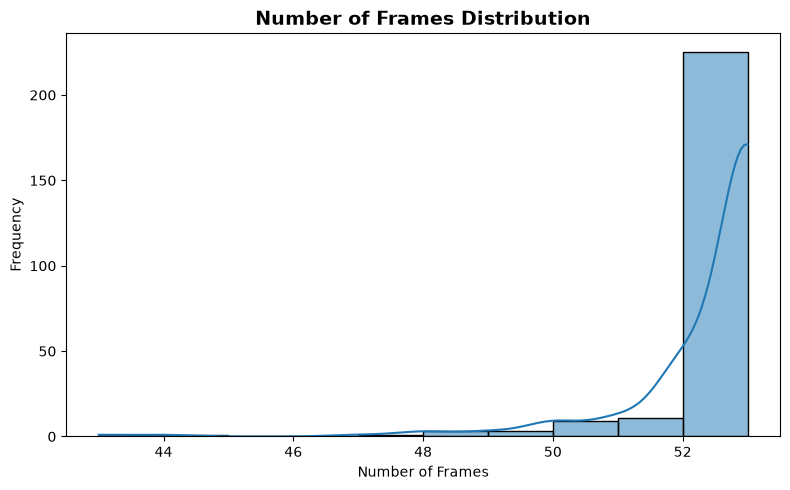

Exported graph to: ../outputs\number_of_frames_distribution.png


In [22]:
# Number of Frames Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="number_of_frames",
    bins=10,
    kde=True
)

plt.title("Number of Frames Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Number of Frames")
plt.ylabel("Frequency")
plt.tight_layout()

# Export Graph
frames_path = os.path.join(
    output_dir, "number_of_frames_distribution.png"
)

plt.savefig(frames_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Exported graph to: {frames_path}")

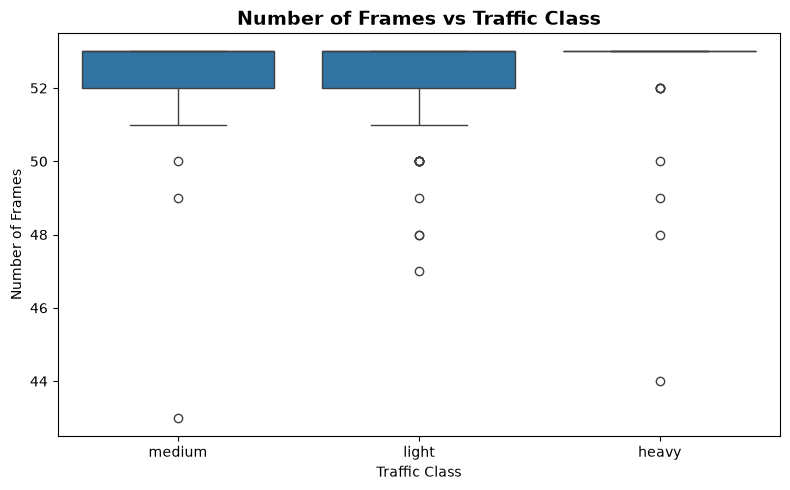

Exported graph to: ../outputs\frames_vs_traffic_class.png


In [23]:
# Number of Frames vs Traffic Class
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="traffic_class",
    y="number_of_frames"
)

plt.title(
    "Number of Frames vs Traffic Class",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Traffic Class")
plt.ylabel("Number of Frames")
plt.tight_layout()

# Export Graph
frames_class_path = os.path.join(
    output_dir, "frames_vs_traffic_class.png"
)

plt.savefig(frames_class_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Exported graph to: {frames_class_path}")

In [24]:
# Calculate mean number of frames
mean_frames = df.groupby("traffic_class")["number_of_frames"].mean()

print("Mean number of frames by traffic class:")
print(mean_frames)

Mean number of frames by traffic class:
traffic_class
heavy     52.431818
light     52.448485
medium    52.355556
Name: number_of_frames, dtype: float64


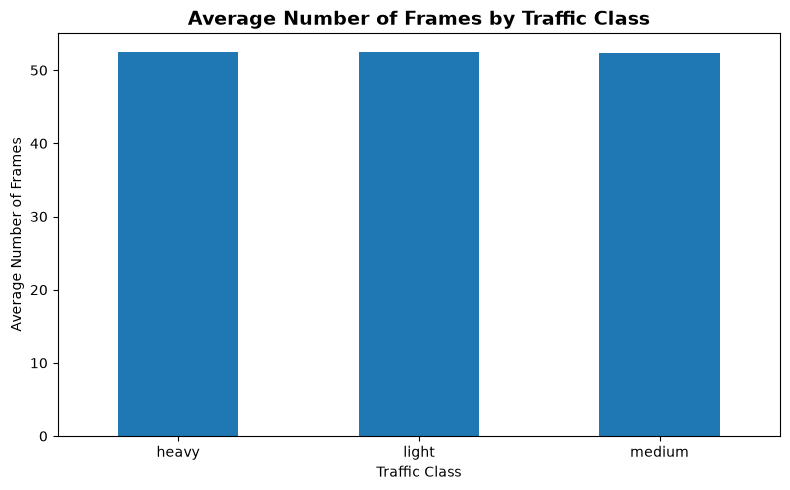

Exported graph to: ../outputs\average_frames_by_traffic_class.png


In [25]:
# Mean Frames by Traffic Class
plt.figure(figsize=(8,5))

mean_frames.plot(kind="bar")

plt.title(
    "Average Number of Frames by Traffic Class",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Traffic Class")
plt.ylabel("Average Number of Frames")
plt.xticks(rotation=0)
plt.tight_layout()

# Export Graph
mean_frames_path = os.path.join(
    output_dir, "average_frames_by_traffic_class.png"
)

plt.savefig(mean_frames_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Exported graph to: {mean_frames_path}")

In [26]:
# Select numerical columns
numeric_columns = [
    "date",
    "timestamp",
    "start_frame",
    "number_of_frames"
]

corr_matrix = df[numeric_columns].corr()

print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                     date  timestamp  start_frame  number_of_frames
date              1.00000  -0.523780          NaN          0.001260
timestamp        -0.52378   1.000000          NaN          0.006748
start_frame           NaN        NaN          NaN               NaN
number_of_frames  0.00126   0.006748          NaN          1.000000


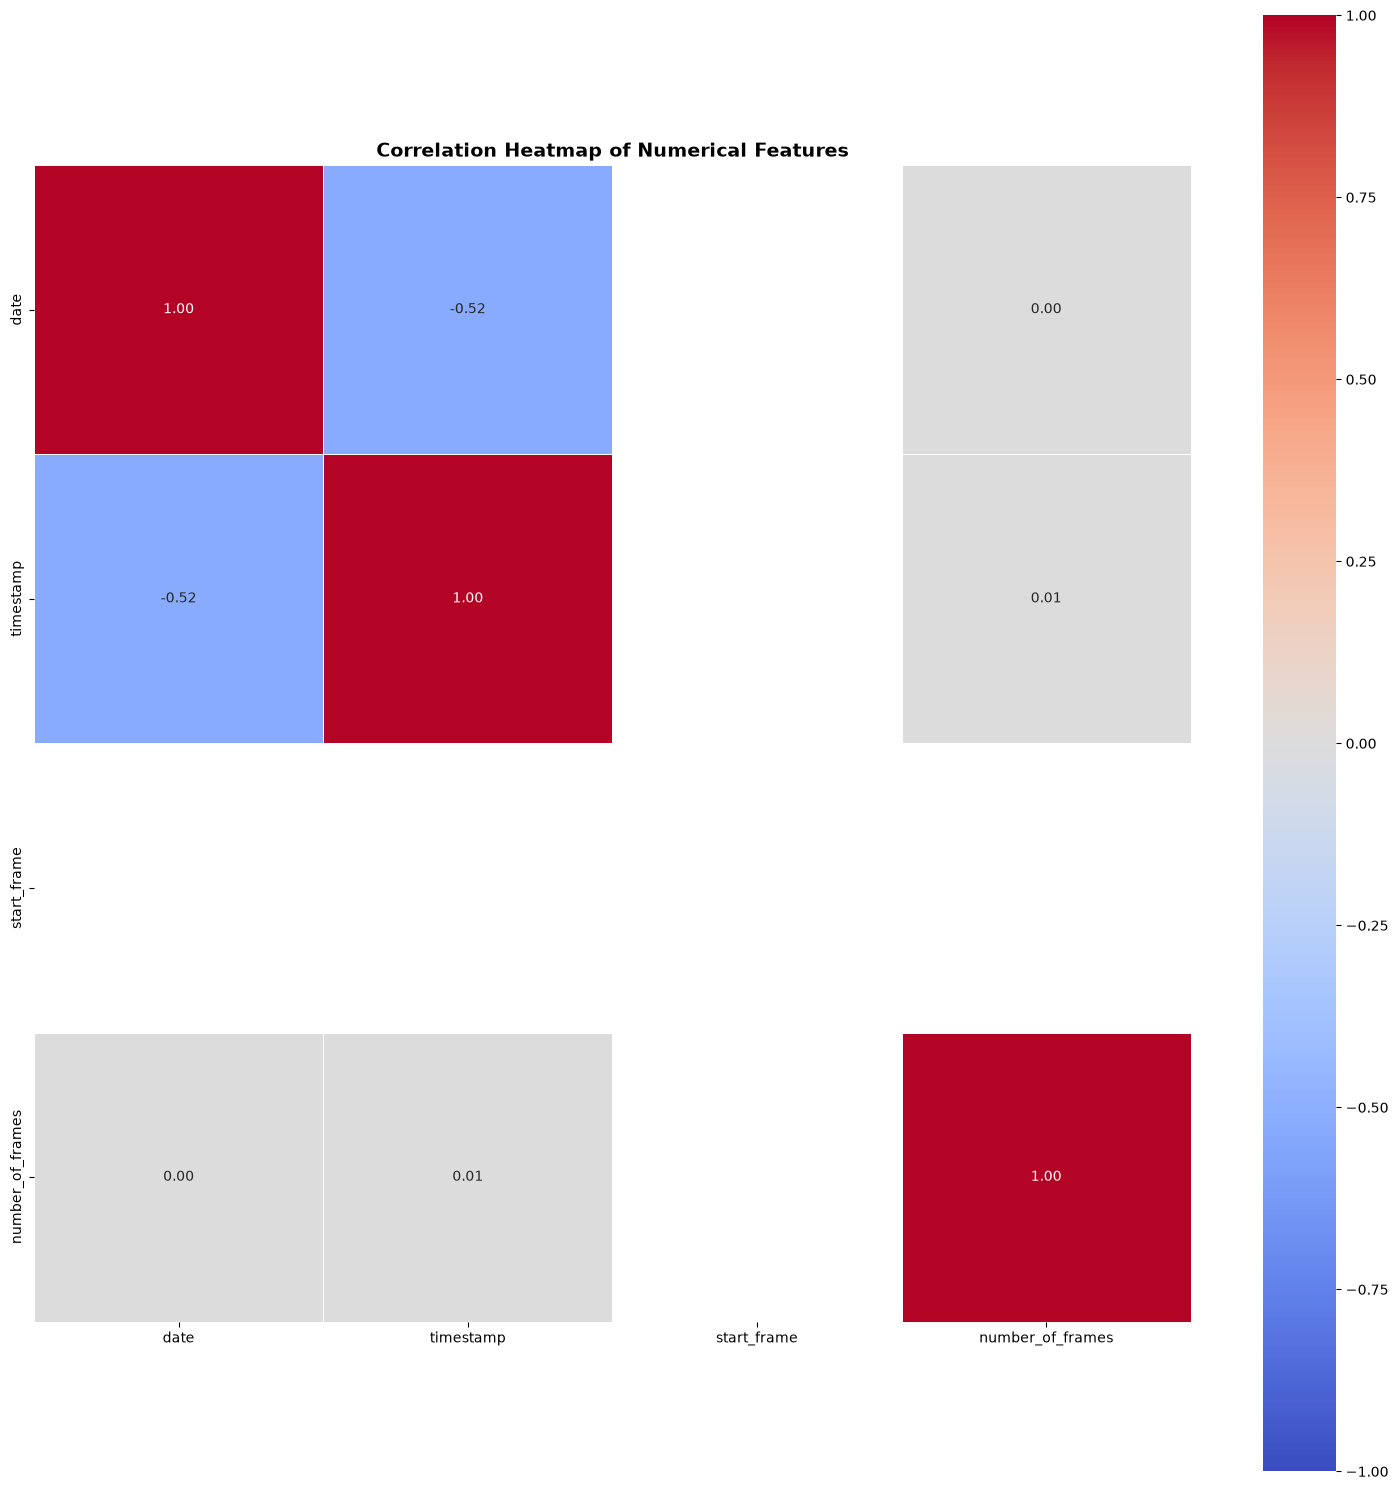

Exported heatmap to: ../outputs\correlation_heatmap.png


In [27]:

# Create Heatmap
plt.figure(figsize=(15,15))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

# Export Heatmap
heatmap_path = os.path.join(
    output_dir,
    "correlation_heatmap.png"
)

plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Exported heatmap to: {heatmap_path}")

In [28]:
# Create Cross Tabulation
weather_class = pd.crosstab(
    df["weather"],
    df["traffic_class"]
)

print("Weather vs Traffic Class:")
print(weather_class)

Weather vs Traffic Class:
traffic_class  heavy  light  medium
weather                            
clear             15     24      12
overcast          27     67      31
rain               2     74       2


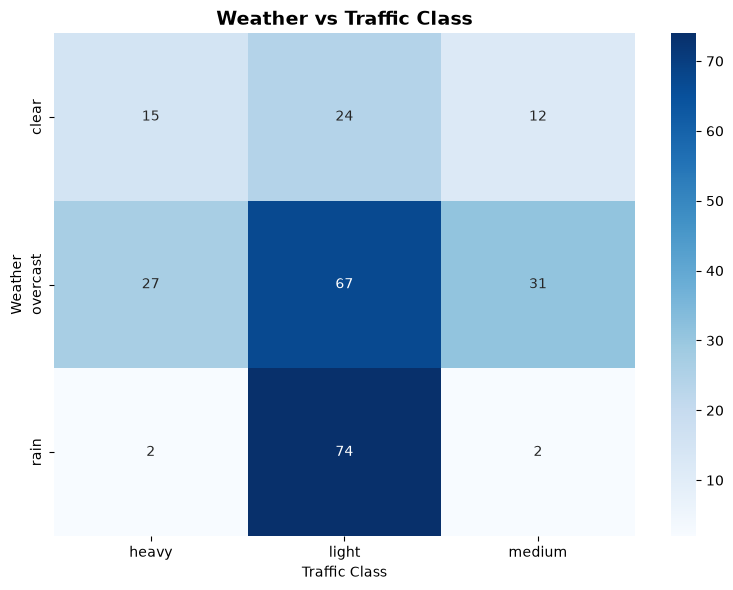

Exported heatmap to: ../outputs\weather_class_heatmap.png


In [29]:
# Create Weather vs Traffic Class Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    weather_class,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Weather vs Traffic Class",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Traffic Class")
plt.ylabel("Weather")
plt.tight_layout()

# Export Heatmap
weather_class_path = os.path.join(
    output_dir,
    "weather_class_heatmap.png"
)

plt.savefig(
    weather_class_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Exported heatmap to: {weather_class_path}")

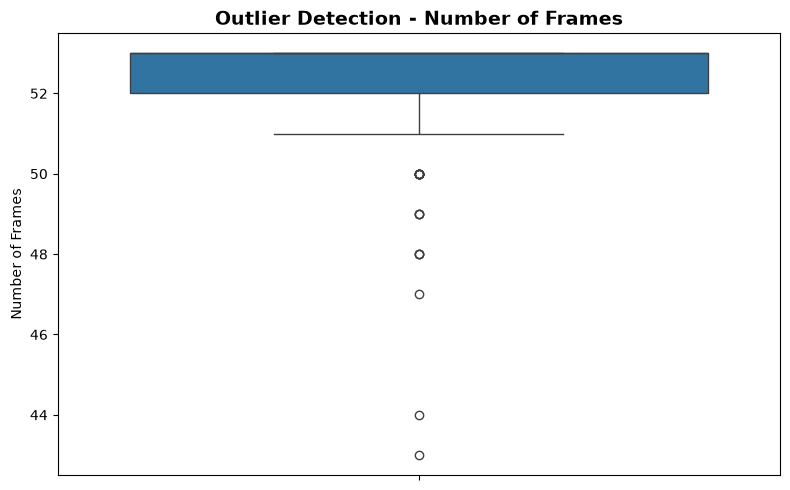

Exported graph to: ../outputs\number_of_frames_outliers.png


In [30]:
# Outlier Detection using Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    y="number_of_frames"
)

plt.title(
    "Outlier Detection - Number of Frames",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Number of Frames")
plt.tight_layout()

# Export Graph
outlier_path = os.path.join(
    output_dir,
    "number_of_frames_outliers.png"
)

plt.savefig(outlier_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Exported graph to: {outlier_path}")

In [31]:
# Calculate Q1 and Q3
Q1 = df["number_of_frames"].quantile(0.25)
Q3 = df["number_of_frames"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Find outliers
outliers = df[
    (df["number_of_frames"] < lower_limit) |
    (df["number_of_frames"] > upper_limit)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

print("\nNumber of outliers:", len(outliers))

display(outliers)

Q1: 52.0
Q3: 53.0
IQR: 1.0
Lower Limit: 50.5
Upper Limit: 54.5

Number of outliers: 18


,filename,date,timestamp,direction,day_night,weather,start_frame,number_of_frames,traffic_class,notes
2,cctv052x2004080516x01640,20040805,16.01640,south,day,overcast,2,48,light,NaN
8,cctv052x2004080516x01646,20040805,16.01646,south,day,overcast,2,49,heavy,NaN
47,cctv052x2004080519x01686,20040805,19.01686,south,day,overcast,2,49,light,NaN
62,cctv052x2004080606x01821,20040806,6.01821,south,day,rain,2,47,light,NaN
67,cctv052x2004080606x01827,20040806,6.01827,south,day,rain,2,50,light,NaN
95,cctv052x2004080608x01855,20040806,8.01855,south,day,rain,2,50,light,NaN
106,cctv052x2004080609x01866,20040806,9.01866,south,day,rain,2,50,light,NaN
108,cctv052x2004080609x01869,20040806,9.01869,south,day,overcast,2,50,light,NaN
123,cctv052x2004080610x01884,20040806,10.01884,south,day,rain,2,50,light,NaN
147,cctv052x2004080612x00003,20040806,12.00003,south,day,rain,2,50,light,NaN


In [32]:
class_percentage = (
    df["traffic_class"]
    .value_counts(normalize=True) * 100
)

print("Traffic Class Percentage:")
print(class_percentage.round(2))

Traffic Class Percentage:
traffic_class
light     64.96
medium    17.72
heavy     17.32
Name: proportion, dtype: float64


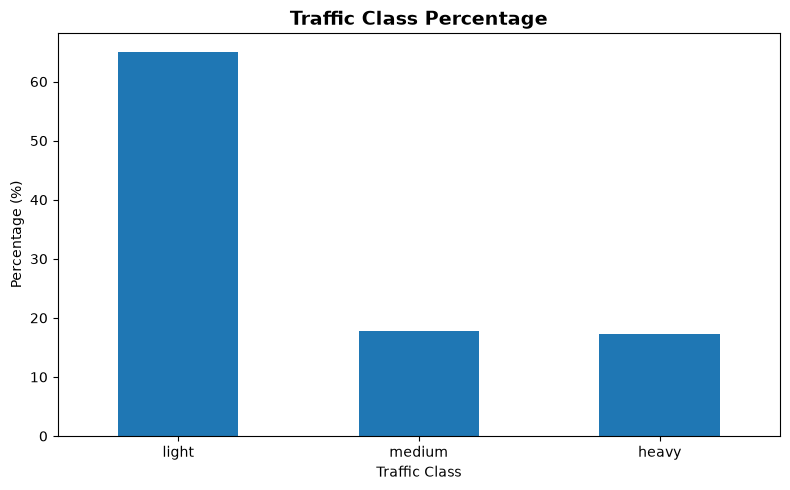

Exported graph to: ../outputs\traffic_class_percentage.png


In [33]:
# Traffic Class Percentage
plt.figure(figsize=(8,5))

class_percentage.plot(kind="bar")

plt.title(
    "Traffic Class Percentage",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Traffic Class")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()

# Export Graph
percentage_path = os.path.join(
    output_dir,
    "traffic_class_percentage.png"
)

plt.savefig(percentage_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Exported graph to: {percentage_path}")

## Final observation
The dataset was analyzed using statistical summaries and visualizations.
Light traffic has the highest number of samples compared with Medium and Heavy traffic.
Weather, day/night, and direction distributions were analyzed using graphs.
Relationships between traffic class and other features were visualized.
The EDA helped understand the dataset and identify patterns useful for modelling.